In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [11]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 1379/1379 [00:00<00:00, 54368.56 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
num_labels = 1

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(10.6868, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

# 5. Top Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
init_metric = eval_loop(model, val_dataloader, task_name, device, regression=True)[0]
init_metric

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [36]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9, 
    teacher_model=teacher_model, drop_strategy="top", regression=True
)

Target Metric for stsb: pearson
Original pearson score: 0.9001
Recovery threshold: 0.0090

Merge Iteration: 1/9
Number of Layers Remaining: 11
  Metrics:
    ★ pearson: 0.8742
      spearmanr: 0.8764
  Performance drop: 0.0258 (threshold: 0.0090)
  → Recovery training NEEDED
  → Training: 10 epochs, lr=1e-05


Training:   0%|          | 0/1800 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/drop_layer_strategy/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 180/1800 [00:45<06:16,  4.30it/s]

✓ Saved checkpoint (best loss: 0.4717)

<----------------- Epoch 1 ----------------->
Loss: 0.06, Training Metrics:
  pearson: 0.9720
  spearmanr: 0.9697
Validation Loss: 0.47, Validation Metrics:
  pearson: 0.8925
  spearmanr: 0.8901
Elapsed Time: 47.6858 sec


...

Training:  80%|████████  | 1440/1800 [03:14<00:27, 13.13it/s]


<----------------- Epoch 8 ----------------->
Loss: 0.11, Training Metrics:
  pearson: 0.9481
  spearmanr: 0.9397
Validation Loss: 0.7, Validation Metrics:
  pearson: 0.8471
  spearmanr: 0.8450
Elapsed Time: 20.0788 sec


Training:  90%|█████████ | 1620/1800 [03:32<00:23,  7.61it/s]


<----------------- Epoch 9 ----------------->
Loss: 0.1, Training Metrics:
  pearson: 0.9514
  spearmanr: 0.9452
Validation Loss: 0.69, Validation Metrics:
  pearson: 0.8476
  spearmanr: 0.8454
Elapsed Time: 16.9284 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 212.96 sec
Chosen Primary Metric: pearson
Best Metric Run: 0.8477

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 7
    Best val loss: 0.6898
    Best val metrics: {'pearson': 0.8476996609047793, 'spearmanr': 0.8454474883947767}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/top/layer-3-stsb.pt


In [37]:
performance_track

{'performance_track': [{'pearson': 0.900084701022039,
   'spearmanr': 0.8962584593578651},
  {'pearson': 0.8958924019721506, 'spearmanr': 0.8917771164115746},
  {'pearson': 0.8893813573254719, 'spearmanr': 0.8857099503082435},
  {'pearson': 0.8910265912209367, 'spearmanr': 0.8870208106423219},
  {'pearson': 0.8913209200722481, 'spearmanr': 0.8872640243330818},
  {'pearson': 0.8893101201861593, 'spearmanr': 0.8859055500871833},
  {'pearson': 0.8878251471740005, 'spearmanr': 0.8839994384531649},
  {'pearson': 0.882201346186011, 'spearmanr': 0.8787143867678875},
  {'pearson': 0.8648676936543573, 'spearmanr': 0.8628634932808288},
  {'pearson': 0.8476996609047793, 'spearmanr': 0.8454474883947767}],
 'remaining_layers': [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
  [0, 1, 2, 3, 4, 5, 6, 7, 8],
  [0, 1, 2, 3, 4, 5, 6, 7],
  [0, 1, 2, 3, 4, 5, 6],
  [0, 1, 2, 3, 4, 5],
  [0, 1, 2, 3, 4],
  [0, 1, 2, 3],
  [0, 1, 2]]}

In [38]:
torch.save(performance_track, f'./weights/top/performance_track_{task_name}.pt')

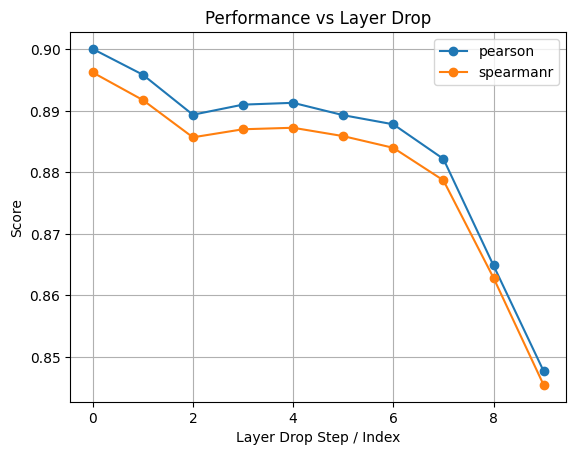

In [39]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()